In [16]:
import numpy as np
import cv2
import matplotlib.pyplot as plt
import os

In [17]:
prototxt_path = "MobileNet-iter-SSD/deploy.prototxt.txt"
caffemodel_path = "MobileNet-iter-SSD/mobilenet_iter_73000.caffemodel"
classes_path = "classes.txt"
image_path="../../photo/cat.jpg"

In [18]:
print("Current Working Directory:", os.getcwd())
print("config Dosyası Var mı?:", os.path.exists(prototxt_path))
print("class Dosyası Var mı?:", os.path.exists(caffemodel_path))
print("label Dosyası Var mı?:", os.path.exists(classes_path))
print("image Dosyası Var mı?:", os.path.exists(image_path))

Current Working Directory: C:\Users\Monster\OneDrive\Masaüstü\OpencvDnn\Caffe\Detection
config Dosyası Var mı?: True
class Dosyası Var mı?: True
label Dosyası Var mı?: True
image Dosyası Var mı?: True


In [19]:

# ---------- Sınıf isimlerini yükle ----------
with open(classes_path, "r") as f:
    class_names = [line.strip() for line in f]

In [20]:
COLORS = np.random.uniform(0, 255, size=(len(class_names), 3))

In [21]:
print("[INFO] loading model...")
net = cv2.dnn.readNetFromCaffe(prototxt_path,caffemodel_path)


[INFO] loading model...


In [22]:
image = cv2.imread(image_path)
(h, w) = image.shape[:2]

In [23]:
blob = cv2.dnn.blobFromImage(cv2.resize(image, (300, 300)), 0.007843, (300, 300), 127.5)

In [24]:
net.setInput(blob)

In [25]:
detections = net.forward()

In [26]:
# Tespitleri döngü ile göster
for i in np.arange(0, detections.shape[2]):
    confidence = detections[0, 0, i, 2]

    if confidence > 0.2:
        idx = int(detections[0, 0, i, 1])
        box = detections[0, 0, i, 3:7] * np.array([w, h, w, h])
        (startX, startY, endX, endY) = box.astype("int")

        label = "{}: {:.2f}%".format(class_names[idx], confidence * 100)
        print("[INFO] {}".format(label))
        cv2.rectangle(image, (startX, startY), (endX, endY), COLORS[idx], 2)
        y = startY - 15 if startY - 15 > 15 else startY + 15
        cv2.putText(image, label, (startX, y), cv2.FONT_HERSHEY_SIMPLEX, 0.5, COLORS[idx], 2)

[INFO] cat: 99.82%


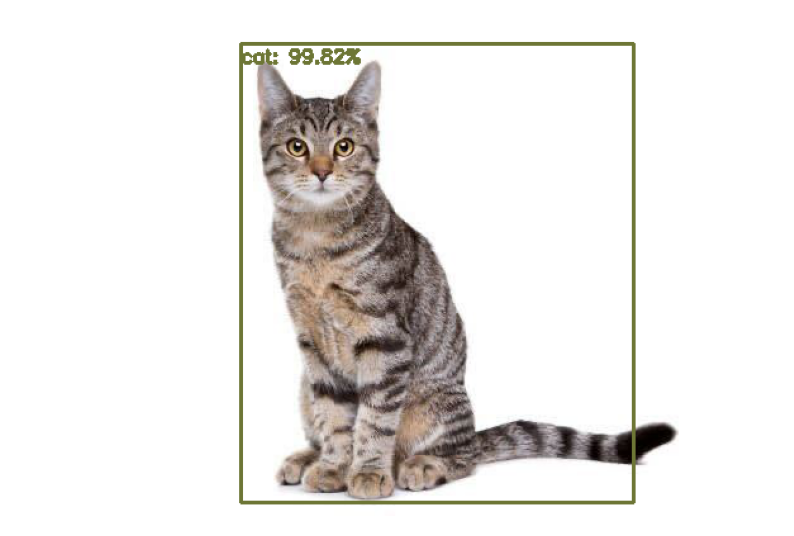

In [27]:
plt.figure(figsize=(10, 8))
plt.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
plt.axis("off")
plt.show()